# CMP

1. Naredite robota podajnega in zajemite trajektorijo v prostoru sklepov na 100 Hz.

2. Izrišite zajeto trajektorijo.

3. Trajektorijo zapišite z uporabo DMP-jev - kodirajte v DMP.

4. Trajektorijo dekodirajte iz DMP-jev in jo narišite na isti plot kot osnovno, zajeto trajektorijo. **Pozor! robot ima 7 sklepov!**

5. Naredite robota togega in izvedite zakodirano trajektorijo (narisite napoko izvedbe na nov graf)

6. Med izvajanjem zajemite krmilne navore v sklepih brez gravitacije (r.state.tau_J_d)

7. Zapisite navore kot TP (torque primitives)

8. Izrisite in primerjajte zajete in dekodirane navore

9. Naredite robota podajnega 

10. Izvedite zajeto pozicijsko trajetorijo (DMP) - pozor zacetna lega

11. ... in izrisite napako izvedbe na isti graf napake kot prej

12. Izvedite CMP (DMP in TP); poglejte vhode za r.GoTo_q

13. ... in izrisite napako izvedbe na isti graf napake kot prej

14. Preizkusite togost robota ob izvedbi CMPja

15. Pogovorite se o CMPjih in napakah z asistentom

16. Napisite celosten robotski program, ki iz zacetne lege najprej pobere rocko in jo premakne na koncno lego (DMP togo, DMP podajno, CMP podajno) in primerjajte izvedbe (napake)


In [1]:
import rospy
ns = "pingvin_1"
rospy.init_node(ns)
from robotblockset.ros.franka import panda_ros
r = panda_ros(ns=ns, control_strategy="JointImpedance", init_node=False)

ROSException: timeout exceeded while waiting for service /pingvin_1/controller_manager/switch_controller

shutdown request: [/pingvin_1] Reason: new node registered with same name


In [4]:
import time
import numpy as np
def record_robot_state(robot, frequency, duration):
    interval = 1.0 / frequency
    
    N=int(frequency*duration)
    tt = np.zeros((N,1))
    qt = np.zeros((N,r.nj))
    dqt = np.zeros((N,r.nj))

    i = 0
    start_time = time.monotonic()
    end_time = start_time + duration
    
    last_update = time.monotonic()

    while time.monotonic() <= end_time+interval and i < N:
        t = time.monotonic()
        if t - last_update >= interval:
            
            # Get robot state
            state = robot.GetState()
            
            tt[i] = t-start_time
            qt[i] = r.q
            dqt[i] = r.qdot

            # Update the last recorded time
            last_update = t
            i += 1
        
    return tt, qt, dqt, i, N    



**1. Naredite robota podajnega in zajemite trajektorijo v prostoru sklepov na 100 Hz.**

In [5]:
r.SetJointCompliant() 

:Joint compliance changed 
Stiff:[0. 0. 0. 0. 0. 0. 0.]
Damp:[0. 0. 0. 0. 0. 0. 0.]


In [8]:
from utils import pip

time.sleep(1)
print ("start")
pip();
# vzorčimo 3 sekunde pri 100Hz
tt, qt, dqt, i, N = record_robot_state(r,100,3)
pip();
print ("stop")

start
stop


In [ ]:
import utils
from utils import SoftSetJointCompliance
r.ResetCurrentTarget()
SoftSetJointCompliance(r,r._franka_default.JointCompliance.K,4)

**2. Izrišite zajeto trajektorijo.**

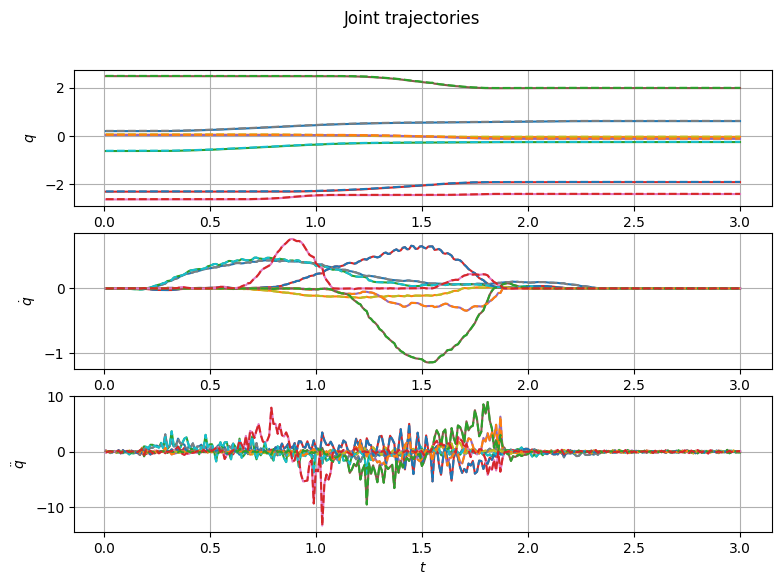

In [9]:
from robotblockset.graphics import plotjtraj
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 1, figsize=(9, 6))
fig.suptitle('Joint trajectories')
plotjtraj(tt, qt, dqt, ax=ax);
plotjtraj(tt, qt+0.01, dqt, ax=ax, linestyle="--");


**3. Trajektorijo zapišite z uporabo DMP-jev - kodirajte v DMP.**

DMP(  a_x=2.0,
  a_z=48.0,
  b_z=12.0,
  num_weights=25,
  y0=[ 0.2035991   0.05888607 -0.6186654  -2.29638237  0.042458    2.47456732
 -2.61666776],
  goal=[ 0.61678297 -0.03491936 -0.24793545 -1.90288042 -0.11508083  1.98174828
 -2.39624862],
  _num_dof=7,
  tau=2.990019296761602
  c=[1.         0.92004441 0.84648172 0.77880078 0.71653131 0.65924063
 0.60653066 0.55803515 0.51341712 0.47236655 0.43459821 0.39984965
 0.36787944 0.33846543 0.31140322 0.2865048  0.26359714 0.24252107
 0.22313016 0.20528966 0.1888756  0.17377394 0.15987975 0.14709647
 0.13533528]
  sigma=[3.59600379e-03 3.04395149e-03 2.57664931e-03 2.18108655e-03
 1.84624991e-03 1.56281681e-03 1.32289587e-03 1.11980717e-03
 9.47896308e-04 8.02376902e-04 6.79197384e-04 5.74928173e-04
 4.86666192e-04 4.11954038e-04 3.48711564e-04 2.95177966e-04
 2.49862754e-04 2.11504255e-04 1.79034487e-04 1.51549421e-04
 1.28283815e-04 1.08589905e-04 9.19193704e-05 7.78080672e-05
 7.78080672e-05]
  _d_t=0.010000064537664222
)


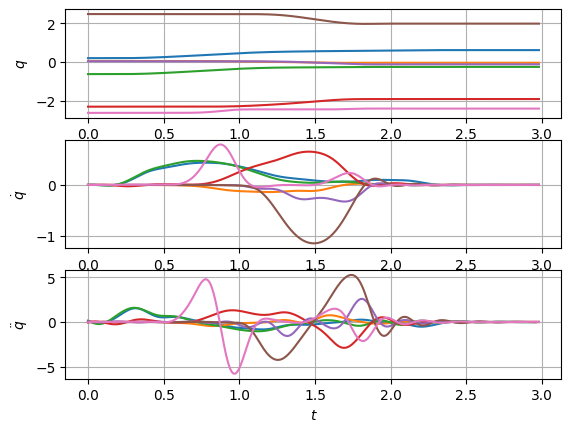

In [10]:
from dmp import DMP

# Za pomoč poglejte zvezek DMP
d = DMP(qt.copy(),np.squeeze(tt.copy()),vel_data=dqt.copy(),num_weights=25)
d1 =DMP(qt.copy(),np.squeeze(tt.copy()),vel_data=dqt.copy(),num_weights=25)
d2 =DMP(qt.copy(),np.squeeze(tt.copy()),vel_data=dqt.copy(),num_weights=25)

print(d1)

d1.a_x = 1
d2.a_x = 4

#d1.b_z = 1
#d2.b_z = 4

#d1.a_z = 1
#d2.a_z = 4

trj_dec,t_dec=d.decode()
trj_dec1,t_dec1=d1.decode()
trj_dec2,t_dec2=d2.decode()



plotjtraj(qt=trj_dec, t=t_dec);


**4. Trajektorijo dekodirajte iz DMP-jev in jo narišite na isti plot kot osnovno, zajeto trajektorijo. **Pozor! robot ima 7 sklepov!****


**5. Naredite robota togega in izvedite zakodirano trajektorijo (narisite napoko izvedbe na nov graf)**

In [11]:
import utils
from utils import SoftSetJointCompliance
r.ResetCurrentTarget()
SoftSetJointCompliance(r,r._franka_default.JointCompliance.K,4)

:Joint compliance changed 
Stiff:[1200. 1200. 1200. 1200.    0.    0.    0.]
Damp:[25 25 25 25 10 10 10]


In [30]:
# Move slowly to the first configuration
r.JMove(qt[0],5)
pip();
napaka=[]
navori=[]
N=np.size(qt,0)
for q, qdot, tm in zip(qt, dqt, np.diff(tt, axis=0)): 
    # Call the GoTo_q function
    navori.append(r.state.tau_J_d)
    r.GoTo_q(q,np.zeros(7),np.zeros(7),0)
    q_d=r.q
    napaka.append(np.linalg.norm(q-q_d))
    
    # time.sleep(1/100.)
    time.sleep(tm[0])

In [29]:
r.state.tau_J_d


(0.6038246321682844,
 0.24552720466012104,
 0.09910764677679201,
 0.7903077694198244,
 0.014117235454558081,
 -0.0030898881405731177,
 -0.006479784389517817)

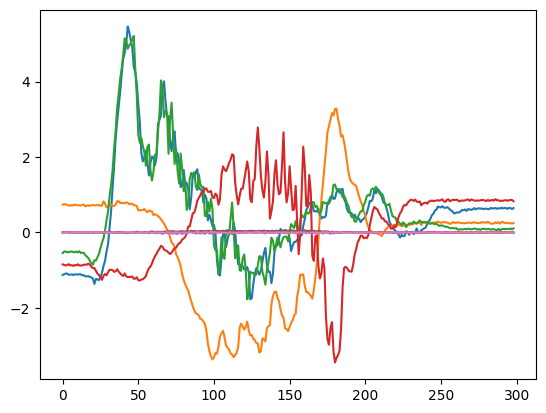

In [25]:
plt.plot(navori)

**6. Med izvajanjem zajemite krmilne navore v sklepih brez gravitacije (r.state.tau_J_d)**

**7. Zapisite navore kot TP (torque primitives)**

In [32]:
tp = DMP(pos_data=navori.copy(),
         time=np.squeeze(tt.copy()[:-1]),
         num_weights=25)

In [33]:
tau_dec, t_tau = tp.decode()

**8. Izrisite in primerjajte zajete in dekodirane navore**

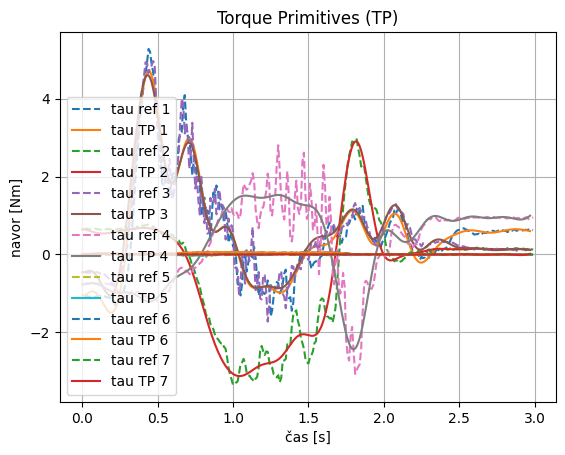

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Pretvorba v numpy
navori = np.array(navori)
tau_dec = np.array(tau_dec)

plt.figure()
for i in range(navori.shape[1]):
    plt.plot(tt[:len(navori)], navori[:, i], '--', label=f"tau ref {i+1}")
    plt.plot(t_tau, tau_dec[:, i], label=f"tau TP {i+1}")

plt.xlabel("čas [s]")
plt.ylabel("navor [Nm]")
plt.title("Torque Primitives (TP)")
plt.legend()
plt.grid()
plt.show()

**9. Naredite robota podajnega**


In [92]:
r.ErrorRecovery()

Panda::Recovering from errors:
 ['cartesian_reflex']
Panda::Attempting to change robot mode from 4


0

In [75]:
r.ResetCurrentTarget()
r.SetJointSoft(0.01)

:Joint compliance changed 
Stiff:[12.  12.  12.  12.   2.5  2.5  1. ]
Damp:[0.25 0.25 0.25 0.25 0.1  0.1  0.1 ]


**10. Izvedite zajeto pozicijsko trajetorijo (DMP) - pozor zacetna lega**

In [84]:
# Move slowly to the first configuration
r.JMove(qt[0],5)
pip();
napaka1=[]
navori1=[]
N=np.size(qt,0)
for q, qdot, tm in zip(qt, dqt, np.diff(tt, axis=0)): 
    # Call the GoTo_q function
    navori1.append(r.state.tau_J_d)
    r.GoTo_q(q,np.zeros(7),np.zeros(7),0)
    q_d=r.q
    #napaka1.append(np.linalg.norm(q-q_d))
    xx,_=r.Kinmodel(q,r.TCP)
    napaka1.append(xx[:3]-r.p)
    
    # time.sleep(1/100.)
    time.sleep(tm[0])

In [70]:
r.p
r.q
xx,_=r.Kinmodel(r.q,r.TCP)
print(xx[:3])
print(r.p)

[0.54430709 0.19686982 0.4214799 ]
[0.54447892 0.19693571 0.42161994]



**11. ... in izrisite napako izvedbe na isti graf napake kot prej**

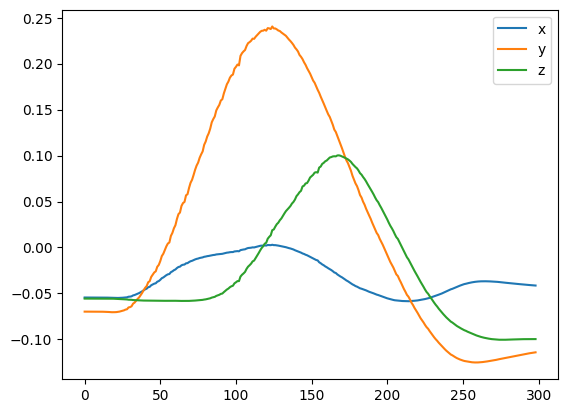

In [85]:
plt.plot(napaka1)
plt.legend(['x', 'y', 'z'])


**12. Izvedite CMP (DMP in TP); poglejte vhode za r.GoTo_q**


In [87]:
import inspect
#from robotblockset.robots import robot
#sig = inspect.signature(robot.CPath)
sig = inspect.signature(r.GoTo_q)
print(sig)

(q, qdot, trq, wait)


In [94]:
# Move slowly to the first configuration
r.JMove(qt[0],5)
pip();
napaka1=[]
navori1=[]
tau_dec = np.vstack([tau_dec, tau_dec[-1]])
N=np.size(qt,0)
for i, (q, qdot, tm) in enumerate(zip(qt, dqt, np.diff(tt, axis=0))): 
    tau_i = tau_dec[i]  

    navori1.append(r.state.tau_J_d)
    
    r.GoTo_q(q, np.zeros(7), tau_i, 0)

    q_d = r.q
    
    xx, _ = r.Kinmodel(q, r.TCP)
    napaka1.append(xx[:3] - r.p)

    time.sleep(tm[0])

**13. ... in izrisite napako izvedbe na isti graf napake kot prej**

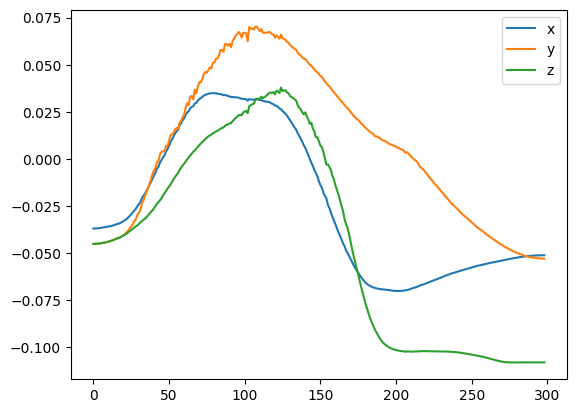

In [95]:
plt.plot(napaka1)
plt.legend(['x', 'y', 'z'])

**14. Preizkusite togost robota ob izvedbi CMPja**

**15. Pogovorite se o CMPjih in napakah z asistentom**

**16. Napisite celosten robotski program, ki iz zacetne lege najprej pobere rocko in jo premakne na koncno lego (DMP togo, DMP podajno, CMP podajno) in primerjajte izvedbe (napake)**

In [ ]:
r.ResetCurrentTarget()
r.SetJointSoft(0.01)

In [96]:
# Move slowly to the first configuration
r.JMove(qt[0],5)
pip();
napaka1=[]
navori1=[]
tau_dec = np.vstack([tau_dec, tau_dec[-1]])
N=np.size(qt,0)
for i, (q, qdot, tm) in enumerate(zip(qt, dqt, np.diff(tt, axis=0))): 
    tau_i = tau_dec[i]  

    navori1.append(r.state.tau_J_d)
    
    r.GoTo_q(q, np.zeros(7), tau_i, 0)

    q_d = r.q
    
    xx, _ = r.Kinmodel(q, r.TCP)
    napaka1.append(xx[:3] - r.p)

    time.sleep(tm[0])

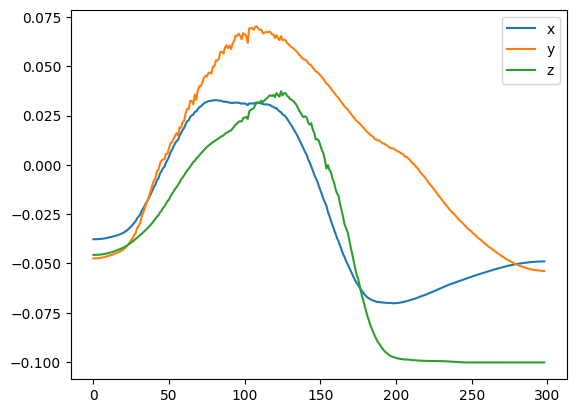

In [97]:
plt.plot(napaka1)
plt.legend(['x', 'y', 'z'])

In [98]:
r.ResetCurrentTarget()
r.SetJointSoft(0.5)

:Joint compliance changed 
Stiff:[600. 600. 600. 600. 125. 125.  50.]
Damp:[12.5 12.5 12.5 12.5  5.   5.   5. ]


In [99]:
# Move slowly to the first configuration
r.JMove(qt[0],5)
pip();
napaka2=[]
navori2=[]
tau_dec = np.vstack([tau_dec, tau_dec[-1]])
N=np.size(qt,0)
for i, (q, qdot, tm) in enumerate(zip(qt, dqt, np.diff(tt, axis=0))): 
    tau_i = tau_dec[i]  

    navori2.append(r.state.tau_J_d)
    
    r.GoTo_q(q, np.zeros(7), tau_i, 0)

    q_d = r.q
    
    xx, _ = r.Kinmodel(q, r.TCP)
    napaka2.append(xx[:3] - r.p)

    time.sleep(tm[0])

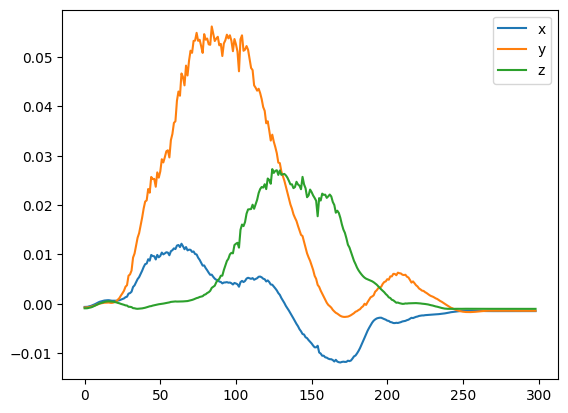

In [100]:
plt.plot(napaka2)
plt.legend(['x', 'y', 'z'])

In [101]:
import utils
from utils import SoftSetJointCompliance
r.ResetCurrentTarget()
SoftSetJointCompliance(r,r._franka_default.JointCompliance.K,4)

:Joint compliance changed 
Stiff:[600. 600. 600. 600. 125. 125.  50.]
Damp:[25 25 25 25 10 10 10]


In [102]:
# Move slowly to the first configuration
r.JMove(qt[0],5)
pip();
napaka3=[]
navori3=[]
tau_dec = np.vstack([tau_dec, tau_dec[-1]])
N=np.size(qt,0)
for i, (q, qdot, tm) in enumerate(zip(qt, dqt, np.diff(tt, axis=0))): 
    tau_i = tau_dec[i]  

    navori3.append(r.state.tau_J_d)
    
    r.GoTo_q(q, np.zeros(7), tau_i, 0)

    q_d = r.q
    
    xx, _ = r.Kinmodel(q, r.TCP)
    napaka3.append(xx[:3] - r.p)

    time.sleep(tm[0])

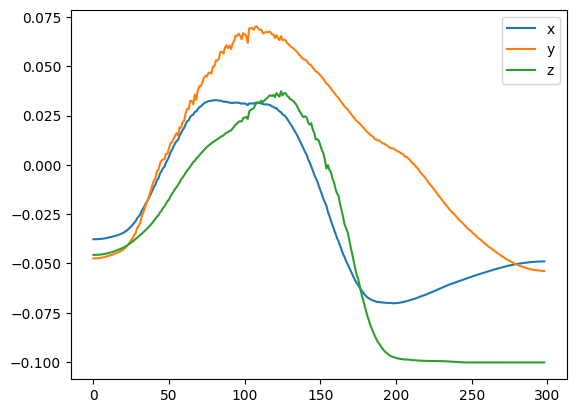

In [103]:
plt.plot(napaka1)
plt.legend(['x', 'y', 'z'])